검증할 이미지 경로를 입력하세요:  /Users/ryk/Desktop/pdflabelwork/testdata/images/1_0.png



image 1/1 /Users/ryk/Desktop/pdflabelwork/testdata/images/1_0.png: 640x480 None43.1ms
Speed: 3.0ms preprocess, 43.1ms inference, 7.3ms postprocess per image at shape (1, 3, 640, 480)

객체(재단선 책등)가 인식된 모서리 개수: 4
결과:  pass
corner_check_results.json 저장 완료


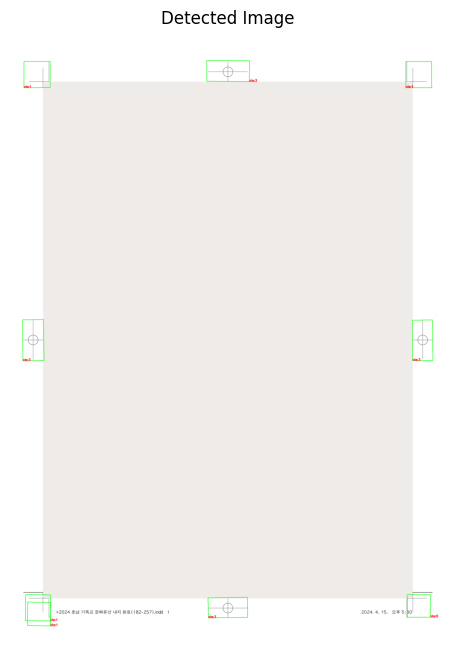

In [1]:
import os
import cv2
import json
import numpy as np
import matplotlib.pyplot as plt
from ultralytics import YOLO


# 모서리 크기 비율(마진율) 정의 함수
def get_corner_regions_ratio(margin_ratio=0.1):  # 모서리부분을 전체 이미지 크기의 0.1 -> 10% 으로 설정
    return {
        'top_left': ((0.0, 0.0), (margin_ratio, margin_ratio)),
        'top_right': ((1 - margin_ratio, 0.0), (1.0, margin_ratio)),
        'bottom_left': ((0.0, 1 - margin_ratio), (margin_ratio, 1.0)),
        'bottom_right': ((1 - margin_ratio, 1 - margin_ratio), (1.0, 1.0))
    }


# 마진율을 픽셀로 환산
def convert_ratios_to_pixels(image_shape, regions_ratio):
    h, w = image_shape[:2]

    regions_pixel = {}

    for name, ((rx1, ry1), (rx2, ry2)) in regions_ratio.items():
        x1 = int(rx1 * w)
        y1 = int(ry1 * h)
        x2 = int(rx2 * w)
        y2 = int(ry2 * h)
        regions_pixel[name] = ((x1, y1), (x2, y2))

    return regions_pixel


# 탐지한 객체 좌표가 모서리 영역에 있는지 검증
def point_in_region(x, y, region):
    (x1, y1), (x2, y2) = region
    return x1 <= x <= x2 and y1 <= y <= y2



# 실행기 경로에서 모델 찾기
model_path = os.path.join(os.getcwd(), 'best9.pt')  # 이 코드가 존재하는 현재 경로를 기준
model = YOLO(model_path)

# 검증할려는 이미지 경로 입력
image_path = input("검증할 이미지 경로를 입력하세요: ").strip()
img = cv2.imread(image_path)

if img is None:
    raise ValueError("이미지가 아닌듯 합니다. 경로를 확인하여 주세요.")
draw_img = img.copy()




# 모서리 영역 크기 계산
corner_ratio_regions = get_corner_regions_ratio(margin_ratio=0.1)  # 한 모서리당 크기는 전체 이미지 크기의 10%의 면적을 차지한다
corner_pixel_regions = convert_ratios_to_pixels(img.shape, corner_ratio_regions)  # 면적 크기를 픽셀단위로 변환


# 미리 학습한 yolo obb로 객체 탐지 실행
results = model(image_path)
json_data = []
corner_hits = set()  # 모서리에서 중복으로 탐지한 객체들을 무시하기위해 set 집합 자료구조 사용



for result in results:
    boxes = result.obb
    if boxes is None:
        print("탐지된 객체가 없습니다")
        continue

    # 좌표 리스트
    coords_list = boxes.xyxyxyxy

    for i in range(len(coords_list)):
        cls = int(boxes.cls[i])
        conf = float(boxes.conf[i])
        coords = coords_list[i].tolist()  # 꼭짓점 4개

        object_corners = set()

        for x, y in coords:
            for corner_name, region in corner_pixel_regions.items():
                if point_in_region(x, y, region):  # 탐지한 객체가 모서리 영역 안쪽에 있는가
                    object_corners.add(corner_name)

        corner_hits.update(object_corners)

        # json 저장용
        json_data.append({
            "class": cls,
            "confidence": round(conf, 4),
            "points": [{"x": round(x, 2), "y": round(y, 2)} for (x, y) in coords],
            "included_corners": list(object_corners)
        })

        #  시각화 obb 박스와 클래스 객체(재단선, 책등) 번호
        pts = [(int(x), int(y)) for x, y in coords]
        cv2.polylines(draw_img, [np.array(pts, dtype=np.int32)], isClosed=True, color=(0, 255, 0), thickness=2)
        cv2.putText(draw_img, f"cls:{cls}", pts[0], cv2.FONT_HERSHEY_SIMPLEX, 0.6, (0, 0, 255), 2)



# 통과여부 판단
hit_count = len(corner_hits)

# 모서리당 최소 1개씩, 총 3개의 모서리에 객체가 존재한다면 통과
passed = hit_count >= 3

print(f"\n객체(재단선 책등)가 인식된 모서리 개수: {hit_count}")
print("결과: ", "pass" if passed else "fail")


# 결과값 json저장 로직
output = {
    "corner_hits": list(corner_hits),
    "passed": passed,
    "objects": json_data
}

# 문자열 utf-8로 json dump
with open("corner_check_results.json", "w", encoding="utf-8") as f:
    json.dump(output, f, ensure_ascii=False, indent=2)
print("corner_check_results.json 저장 완료")


# 주피터노트북에서 탐지한 이미지 보기
draw_rgb = cv2.cvtColor(draw_img, cv2.COLOR_BGR2RGB)
plt.figure(figsize=(10, 8))
plt.imshow(draw_rgb)
plt.title("Detected Image")
plt.axis('off')
plt.show()